MNIST - Modified National Institute of Standards and Technology

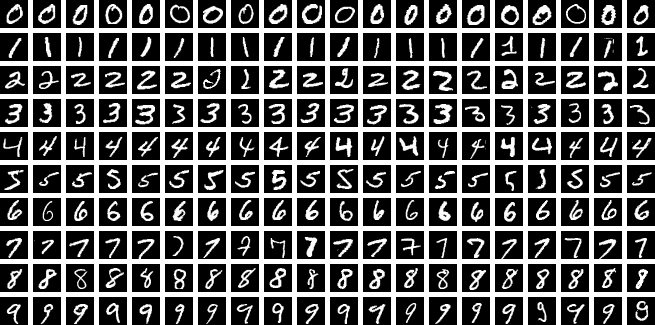


mnist handwritten dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [ ]:
X_train = X_train / 255.0 # to convert the pixel into black and white
X_test = X_test / 255.0


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.fit(X_train, y_train, epochs=5, batch_size=32)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9578 - loss: 0.1439
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9745 - loss: 0.0845
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9802 - loss: 0.0615
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9844 - loss: 0.0477
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9887 - loss: 0.0353


In [ ]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9730 - loss: 0.0995


[0.08416049182415009, 0.9764999747276306]

In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
misclassified_idx = np.where(y_pred != y_true)[0]


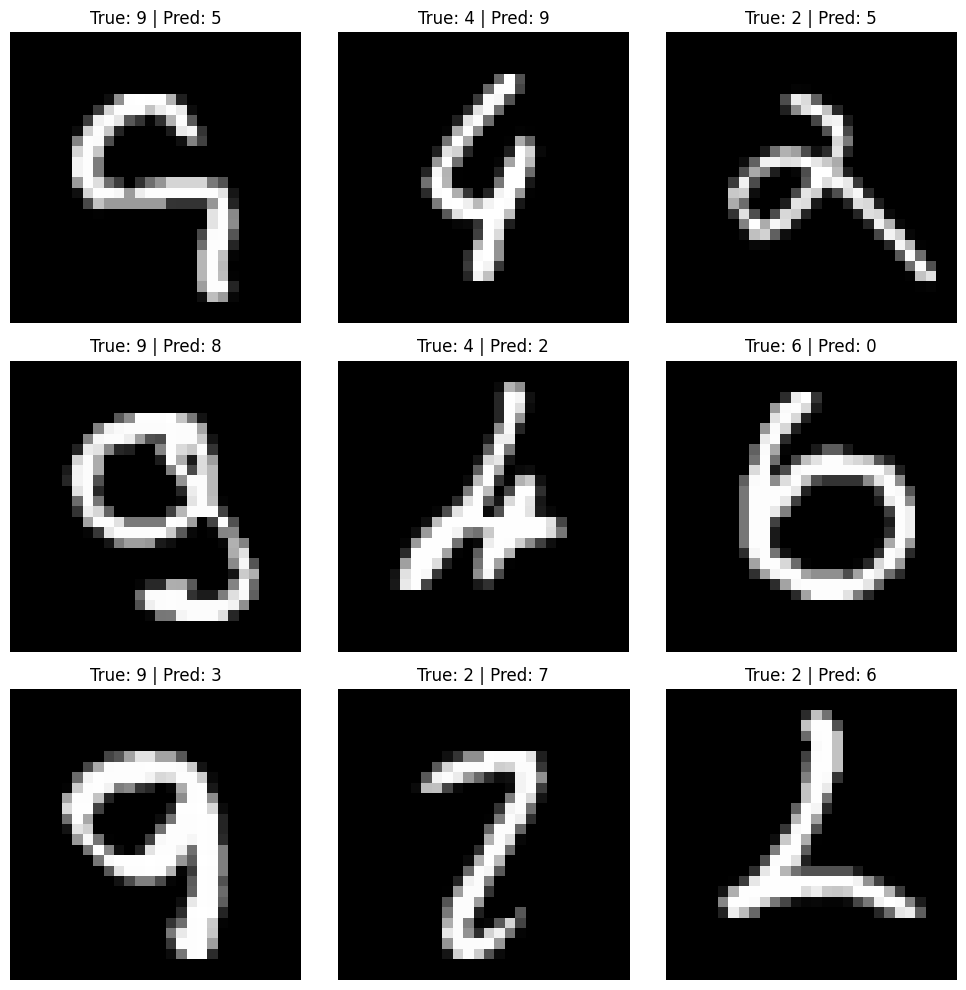

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {y_true[idx]} | Pred: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

error_counts = Counter(y_true[misclassified_idx])
print(error_counts)


Counter({np.int64(8): 46, np.int64(9): 36, np.int64(7): 32, np.int64(4): 27, np.int64(2): 22, np.int64(5): 19, np.int64(3): 15, np.int64(0): 14, np.int64(6): 12, np.int64(1): 12})


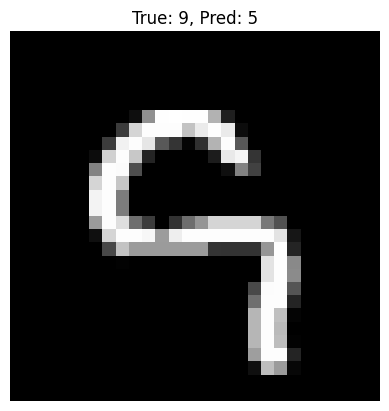

Prediction probabilities:
0: 0.00
1: 0.00
2: 0.00
3: 0.00
4: 0.00
5: 0.95
6: 0.00
7: 0.00
8: 0.00
9: 0.04


In [ ]:
idx = misclassified_idx[0]

plt.imshow(X_test[idx], cmap='gray')
plt.title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
plt.axis('off')
plt.show()

print("Prediction probabilities:")
for i, prob in enumerate(y_pred_prob[idx]):
    print(f"{i}: {prob:.2f}")
